In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import models
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

models.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [2]:
sample_name="151507"
n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7
data_dir  = '/home/pxy/home/pxy/data/DLPFC/st/'

# data_file = f"../dataset/DLPFC/{sample_name}.h5ad"
# adata = sc.read_h5ad(data_file)
adata = sc.read_visium(data_dir + sample_name)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 4226 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [3]:
import pandas as pd

meta = pd.read_csv(
    data_dir+sample_name+"/metadata.tsv",
    sep="\t"
)

meta = meta.set_index("barcode")
adata.obs["Region"] = meta.loc[
    adata.obs_names,
    "layer_guess_reordered"
]
print(adata.obs["Region"].value_counts())
print("NA spots:", adata.obs["Region"].isna().sum())

Region
Layer3    1215
Layer1     817
Layer5     675
Layer6     486
Layer4     369
WM         354
Layer2     305
Name: count, dtype: int64
NA spots: 5


In [4]:
adata = models.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = models.prepare_graph(adata, "spatial")
g_expr = models.prepare_graph(adata, "expr", metric="euclidean")
graph_dict = {"spatial": g_spatia, "expr":g_expr}

normalized data ---------------->
正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 使用 PCA 降维特征 
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [5]:
model = models.model_TwoStage(
    adata.obsm["X_pca"], 
    graph_dict, 
    n_clusters=n_clusters,
    dim_input=200,
    pretrain_epochs=100,   # 预训练200轮
    finetune_epochs=100,   # 训练300轮
    gamma=0.0,             # 重构损失权重
    beta=0.0,              # 聚类损失权重=0 (关键!)
    kappa=1.0,             # 对比损失权重
    theta=0.8,
    dim_hidden=32,
    freeze_encoder=False,   # 冻结预训练编码器
    graph_corr=0.2,
    dropout=0.0,
    gate_bias=1.0,
    residual_weight=0.2
)

In [6]:
pred, embed, gated_weights = model.train()

Stage 1: Pre-training Shared Encoder


Pretrain:  35%|███▌      | 35/100 [00:01<00:01, 40.48it/s]

  Pretrain Epoch 10: Rec Loss = 10.300610
  Pretrain Epoch 20: Rec Loss = 10.127488
  Pretrain Epoch 30: Rec Loss = 10.009749
  Pretrain Epoch 40: Rec Loss = 9.939872


Pretrain:  72%|███████▏  | 72/100 [00:01<00:00, 86.97it/s]

  Pretrain Epoch 50: Rec Loss = 9.909422
  Pretrain Epoch 60: Rec Loss = 9.881548
  Pretrain Epoch 70: Rec Loss = 9.860699
  Pretrain Epoch 80: Rec Loss = 9.838216


...

  Train Epoch 80: Loss = 8.339149,Rec Loss = 10.354903, Contrast Loss = 8.288055, Smooth Loss = 0.063867


Finetune:  91%|█████████ | 91/100 [00:08<00:00, 10.68it/s]

  Train Epoch 90: Loss = 8.327313,Rec Loss = 10.357525, Contrast Loss = 8.279163, Smooth Loss = 0.060187


Finetune: 100%|██████████| 100/100 [00:09<00:00, 10.85it/s]

  Train Epoch 100: Loss = 8.316678,Rec Loss = 10.359791, Contrast Loss = 8.271111, Smooth Loss = 0.056960

  Finetune Epoch 100:
    Total Loss   = 8.3167
    Rec Loss     = 10.3598
    Contrast Loss = 8.2711
    Smooth Loss = 0.0570

✓ Finetune finished (max epochs reached)


In [7]:
# ========== 聚类 ==========
adata.obsm["model_twostage"] = embed
models.clustering(adata, n_clusters, key="model_twostage", refinement=True,cluster_methods='kmeans')

# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]
ARI_kmeans = adjusted_rand_score(adata_filtered.obs["Region"], 
                          adata_filtered.obs["kmeans_refined"])
print(f"\nFinal ARI on {sample_name}: {ARI_kmeans:.4f}")



Final ARI on 151507: 0.5837


In [8]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
mask = adata.obs.Region.notna()
X = embed[mask]
labels = adata.obs["kmeans_refined"][mask]

# 1. 计算 SC 指数
# 注意：样本量巨大时（如 >10万点），silhouette_score 会非常慢，建议下采样
sc_val = silhouette_score(X, labels)

# 2. 计算 CH 指数
ch_val = calinski_harabasz_score(X, labels)

print(f"Internal Evaluation for {sample_name}:")
print(f"Silhouette Coefficient (SC): {sc_val:.4f}")
print(f"Calinski-Harabasz Index (CH): {ch_val:.4f}")

Internal Evaluation for 151507:
Silhouette Coefficient (SC): 0.4964
Calinski-Harabasz Index (CH): 7341.5770


In [9]:
from sklearn.metrics import normalized_mutual_info_score

# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]

# 2. 计算 NMI (新增代码)
NMI_kmeans = normalized_mutual_info_score(adata_filtered.obs["Region"], 
                                          adata_filtered.obs["kmeans_refined"])

print(f"\nFinal Results on {sample_name}:")
print(f"ARI: {ARI_kmeans:.4f}")
print(f"NMI: {NMI_kmeans:.4f}")


Final Results on 151507:
ARI: 0.5837
NMI: 0.7063


In [10]:
from sklearn.metrics import adjusted_mutual_info_score, fowlkes_mallows_score

ami = adjusted_mutual_info_score(adata_filtered.obs["Region"], adata_filtered.obs["kmeans_refined"])
fmi = fowlkes_mallows_score(adata_filtered.obs["Region"], adata_filtered.obs["kmeans_refined"])
print(f"Adjusted Mutual Information (AMI): {ami:.4f}")
print(f"Fowlkes-Mallows Index (FMI): {fmi:.4f}")

Adjusted Mutual Information (AMI): 0.7056
Fowlkes-Mallows Index (FMI): 0.6579


In [11]:
figures_dir = "figures_DLPFC"

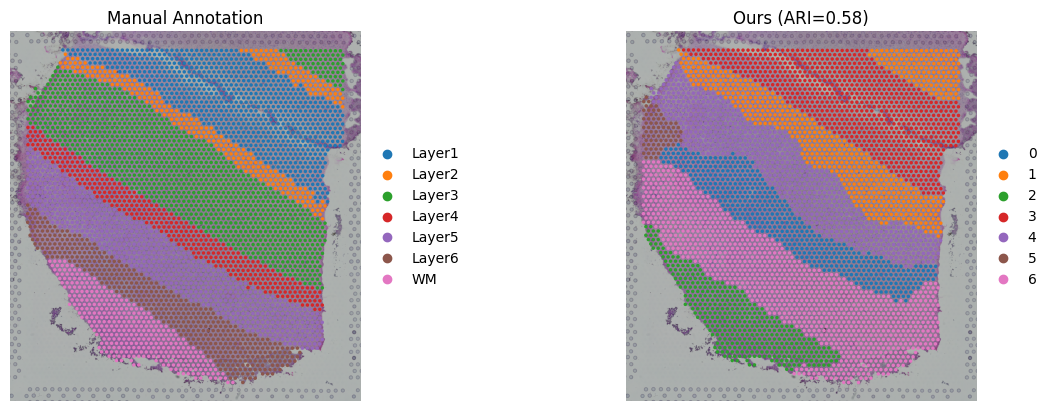

In [12]:
adata_filtered.obs["model"] = adata_filtered.obs["kmeans_refined"]
sc.pl.spatial(adata_filtered, color=["Region", "model"], show=False, frameon=False, title=["Manual Annotation", f"Ours (ARI={round(ARI_kmeans, 2)})"])
plt.savefig(f"{figures_dir}/{sample_name}_spatial_plot.png", dpi=300, bbox_inches='tight')
# 保存 SVG（矢量图，论文首选）
plt.savefig(f"{figures_dir}/{sample_name}_spatial_plot.svg", bbox_inches='tight')
# 保存 PDF（期刊常用）
plt.savefig(f"{figures_dir}/{sample_name}_spatial_plot.pdf", bbox_inches='tight')
plt.show()
plt.close()


In [13]:
adata.obsm["embed"] = embed

In [14]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="embed")

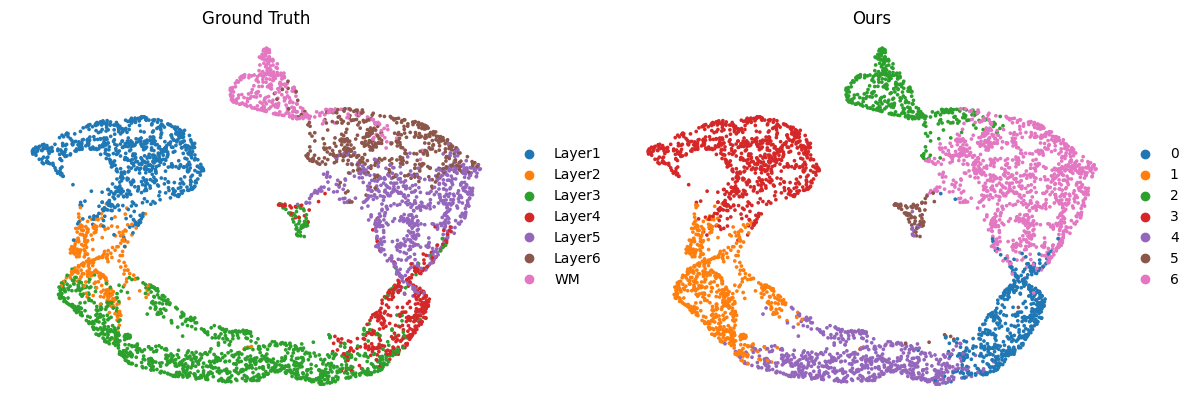

In [15]:

# 计算 UMAP
sc.tl.umap(adata)
sc.settings.vector_friendly = True
# 绘图：同时查看 Ground Truth (Region) 和 你的聚类结果 (kmeans_refined)
# 这样可以直观对比哪些区域分错了
sc.pl.umap(adata[adata.obs['Region'].notna()], color=["Region", "kmeans_refined"], 
           title=["Ground Truth", "Ours"],
           show=False,frameon=False)
           
# 保存图片
plt.savefig(f"{figures_dir}/{sample_name}_umap.png", bbox_inches='tight',dpi=300)
plt.savefig(f"{figures_dir}/{sample_name}_umap.svg", bbox_inches='tight')
plt.savefig(f"{figures_dir}/{sample_name}_umap.pdf", bbox_inches='tight')
plt.show()
plt.close()

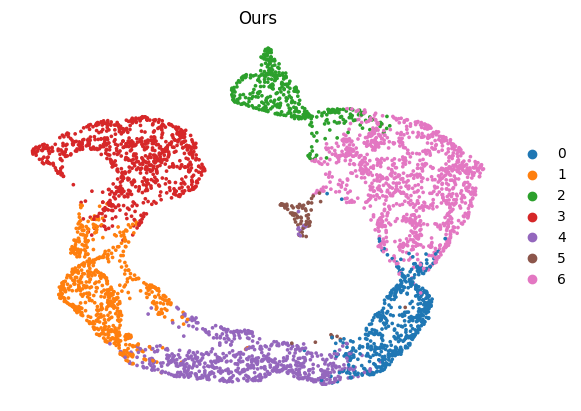

In [16]:
sc.pl.umap(adata[adata.obs['Region'].notna()], color=["kmeans_refined"], 
           title=["Ours"],
           show=False,frameon=False)
# 保存图片
plt.savefig(f"{figures_dir}/{sample_name}_umap_ours.png", bbox_inches='tight',dpi=300)
plt.savefig(f"{figures_dir}/{sample_name}_umap_ours.svg", bbox_inches='tight')
plt.savefig(f"{figures_dir}/{sample_name}_umap_ours.pdf", bbox_inches='tight')
plt.show()
plt.close()

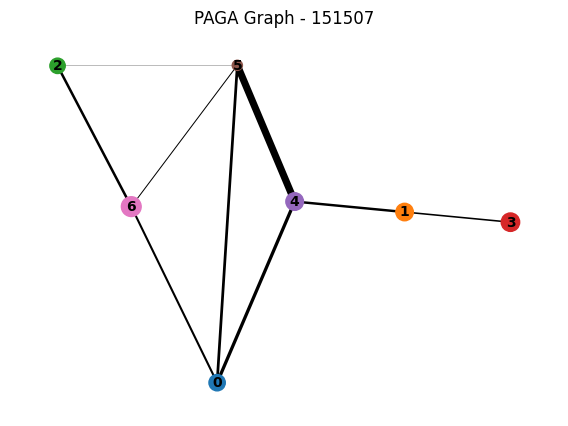

In [17]:
# 计算 PAGA
# groups 指定聚类结果所在的 obs 列名
sc.tl.paga(adata, groups="kmeans_refined")

# 绘图
# plot_threshold 可以控制显示连通性的阈值
sc.pl.paga(adata, color="kmeans_refined", 
           title=f"PAGA Graph - {sample_name}",
           show=False,frameon=False)

# 保存图片
plt.savefig(f"{figures_dir}/{sample_name}_paga.png", bbox_inches='tight',dpi=300)
plt.savefig(f"{figures_dir}/{sample_name}_paga.svg", bbox_inches='tight')
plt.savefig(f"{figures_dir}/{sample_name}_paga.pdf", bbox_inches='tight')
plt.show()
plt.close()
